# Lección 1 — Introducción al Deep Learning y repaso de aprendizaje supervisado

**Repositorio:** `deep-learning-complete-guide`  
**Objetivo:** construir una base sólida para entender los próximos temas de Deep Learning.

---

## Qué vas a aprender

Al terminar este notebook deberías poder:

1. Diferenciar **regresión**, **clasificación**, aprendizaje **supervisado** y **no supervisado**.
2. Entender un modelo como una **función matemática parametrizada**.
3. Distinguir claramente entre **entrenamiento** e **inferencia**.
4. Usar correctamente la notación de **escalares**, **vectores** y **matrices**.
5. Implementar modelos lineales de forma **vectorizada** con NumPy.
6. Calcular e interpretar el **error cuadrático medio**.
7. Entender los esquemas básicos de evaluación: **resustitución**, **hold-out** y **cross-validation**.
8. Resolver ejercicios tipo test del Tema 1.

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### Cómo usar este notebook

Este notebook está pensado para dos usos:

- **Estudiar la asignatura:** cada bloque tiene teoría breve, fórmulas, ejemplos y ejercicios.
- **Publicarlo en GitHub:** el código evita rutas locales, usa datos sintéticos y es reproducible.

Cuando veas un bloque de código, ejecútalo y revisa las formas (`shape`) de las variables. En Deep Learning, muchos errores vienen de dimensiones mal planteadas.

</div>

## 1. Mapa general del Tema 1

El Tema 1 introduce el contexto de la asignatura:

| Bloque | Idea principal |
|---|---|
| Inteligencia Artificial y Machine Learning | Evolución histórica y principales familias de modelos |
| Aprendizaje supervisado | Aprender una función usando pares entrada/salida |
| Aprendizaje no supervisado | Aprender estructura de datos sin etiquetas |
| Modelos generativos | Modelos que generan datos nuevos similares a los de entrenamiento |
| Variables latentes | Representaciones internas de menor dimensión |
| Ética en IA | Sesgos, explicabilidad, uso responsable y concentración de poder |
| Repaso supervisado | Modelos, parámetros, coste, entrenamiento y evaluación |

En este notebook nos centraremos en el bloque que más se necesita para Deep Learning: **modelos supervisados, coste, entrenamiento, evaluación y vectorización**.

## 2. De Machine Learning a Deep Learning

En aprendizaje automático, queremos aprender una función que conecte entradas con salidas.

Por ejemplo:

| Entrada | Salida | Tipo de tarea |
|---|---|---|
| Edad y kilómetros de un coche | Precio estimado | Regresión |
| Texto de una reseña | Positiva / negativa | Clasificación binaria |
| Imagen | Clase de objeto | Clasificación multiclase |
| Imagen médica | Máscara píxel a píxel | Clasificación multivariante |
| Texto | Imagen generada | Modelo generativo condicionado |

La diferencia principal de **Deep Learning** es que el modelo suele ser una red neuronal con muchos parámetros. Aun así, la idea base sigue siendo la misma:

> Un modelo es una función con parámetros que se ajustan durante el entrenamiento.

## 3. Terminología básica

### Regresión

Una tarea de **regresión** predice valores continuos.

Ejemplos:

- precio de una vivienda;
- temperatura de mañana;
- profundidad de cada píxel en una imagen;
- coordenadas de una pose humana.

### Clasificación

Una tarea de **clasificación** predice clases discretas.

Ejemplos:

- spam / no spam;
- perro / gato / caballo;
- tipo de música;
- entidad de cada palabra en una frase.

### Univariante y multivariante

| Concepto | Significado |
|---|---|
| Salida univariante | El modelo devuelve una sola salida |
| Salida multivariante | El modelo devuelve varias salidas |
| Clasificación binaria | Dos clases |
| Clasificación multiclase | Más de dos clases |
| Regresión | Valores reales continuos |

## 4. Notación matemática

En la asignatura se usa una notación muy importante:

| Notación | Significado | Ejemplo |
|---|---|---|
| $x$ | Escalar | una edad |
| $\mathbf{x}$ | Vector | varias características de una muestra |
| $\mathbf{X}$ | Matriz | muchas muestras con muchas características |
| $y$ | Salida escalar | precio |
| $\mathbf{y}$ | Vector de salidas | etiquetas de muchas muestras |
| $\mathbf{w}$ | Vector de parámetros | pesos del modelo |
| $b$ | Sesgo o bias | término independiente |

Un modelo supervisado se puede escribir como:

$$
\hat{y} = f(\mathbf{x}; \mathbf{w})
$$

donde:

- $\mathbf{x}$ es la entrada;
- $\mathbf{w}$ son los parámetros aprendibles;
- $\hat{y}$ es la predicción del modelo.

<div style="background:rgba(217,154,0,0.14);border-left:5px solid #d99a00;padding:14px;border-radius:6px;color:inherit">

### Idea clave para examen

**Entrenar** no es calcular la salida.  
**Entrenar** es encontrar los parámetros del modelo.

Una vez entrenado, en **inferencia** usamos esos parámetros para predecir la salida de nuevos datos.

</div>

## 5. Entrenamiento frente a inferencia

### Inferencia

La inferencia consiste en aplicar el modelo a una entrada:

$$
\hat{y} = f(\mathbf{x}; \mathbf{w})
$$

Aquí los parámetros $\mathbf{w}$ ya están fijados.

### Entrenamiento

El entrenamiento consiste en buscar los parámetros que minimizan una función de coste:

$$
\hat{\mathbf{w}} = \arg\min_{\mathbf{w}} J(\mathbf{w})
$$

La función de coste mide cómo de malas son las predicciones del modelo.

## 6. Dataset supervisado

Un conjunto de entrenamiento supervisado se representa como:

$$
D = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}
$$

donde:

- $N$ es el número de muestras;
- $\mathbf{x}_i$ es la entrada de la muestra $i$;
- $y_i$ es la salida correcta de la muestra $i$.

En forma matricial, si tenemos $N$ muestras y $d$ características:

$$
\mathbf{X} \in \mathbb{R}^{N \times d}
$$

y si cada muestra tiene una única salida:

$$
\mathbf{y} \in \mathbb{R}^{N \times 1}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibilidad
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Configuración sencilla para las figuras
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

## 7. Ejemplo base: regresión lineal 1D

Vamos a generar un conjunto de datos sintético.

Supongamos que existe una relación aproximadamente lineal:

$$
y = 2 + 1.5x + \varepsilon
$$

donde $\varepsilon$ es ruido.

Shape de x: (40,)
Shape de y: (40,)


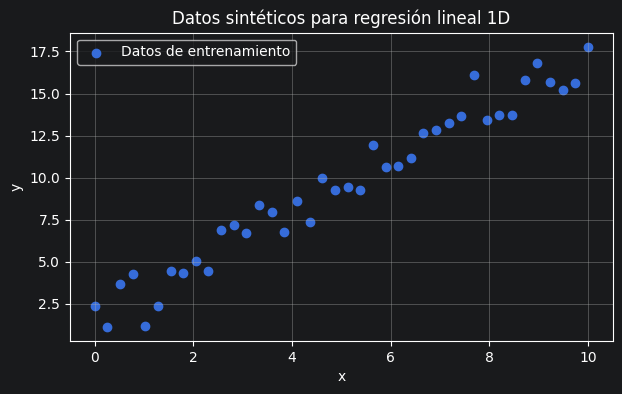

In [2]:
# Generamos datos sintéticos para regresión 1D
N = 40

x = np.linspace(0, 10, N)
noise = rng.normal(loc=0.0, scale=1.2, size=N)
y = 2.0 + 1.5 * x + noise

print("Shape de x:", x.shape)
print("Shape de y:", y.shape)

plt.scatter(x, y, label="Datos de entrenamiento")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos sintéticos para regresión lineal 1D")
plt.legend()
plt.show()

## 8. Modelo lineal 1D

Un modelo lineal de una variable se escribe como:

$$
\hat{y} = f(x; \mathbf{w}) = w_0 + w_1x
$$

donde:

- $w_0$ es el término independiente o **bias**;
- $w_1$ es la pendiente;
- $\mathbf{w} = (w_0, w_1)$ son los parámetros del modelo.

El entrenamiento consiste en buscar los valores de $w_0$ y $w_1$ que mejor ajustan los datos.

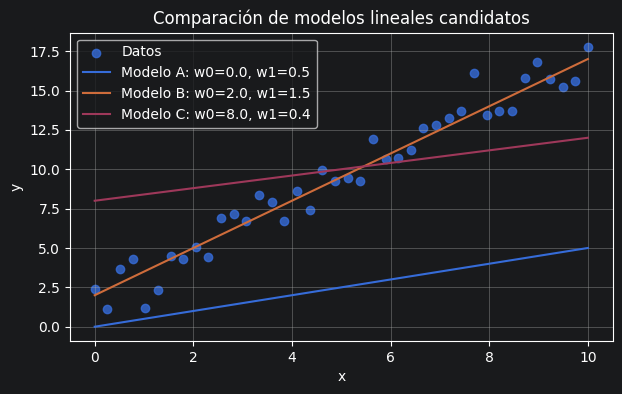

In [3]:
def linear_model_1d(x, w0, w1):
    """Modelo lineal 1D: y_hat = w0 + w1*x."""
    return w0 + w1 * x


# Probamos tres modelos candidatos
candidates = [
    {"w0": 0.0, "w1": 0.5, "name": "Modelo A"},
    {"w0": 2.0, "w1": 1.5, "name": "Modelo B"},
    {"w0": 8.0, "w1": 0.4, "name": "Modelo C"},
]

plt.scatter(x, y, label="Datos", alpha=0.8)

for model in candidates:
    y_hat = linear_model_1d(x, model["w0"], model["w1"])
    plt.plot(x, y_hat, label=f'{model["name"]}: w0={model["w0"]}, w1={model["w1"]}')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparación de modelos lineales candidatos")
plt.legend()
plt.show()

## 9. Función de coste: error cuadrático medio

Para regresión, una función de coste muy habitual es el **MSE** o error cuadrático medio:

$$
J(\mathbf{w}) =
\frac{1}{N}
\sum_{i=1}^{N}
\left(
f(x_i; \mathbf{w}) - y_i
\right)^2
$$

En el caso lineal 1D:

$$
J(w_0, w_1) =
\frac{1}{N}
\sum_{i=1}^{N}
\left(
w_0 + w_1x_i - y_i
\right)^2
$$

El mejor modelo será el que tenga menor coste.
![1_n37x4cBieB5LBmOZCioSBw.gif](Animations/1_n37x4cBieB5LBmOZCioSBw.gif)
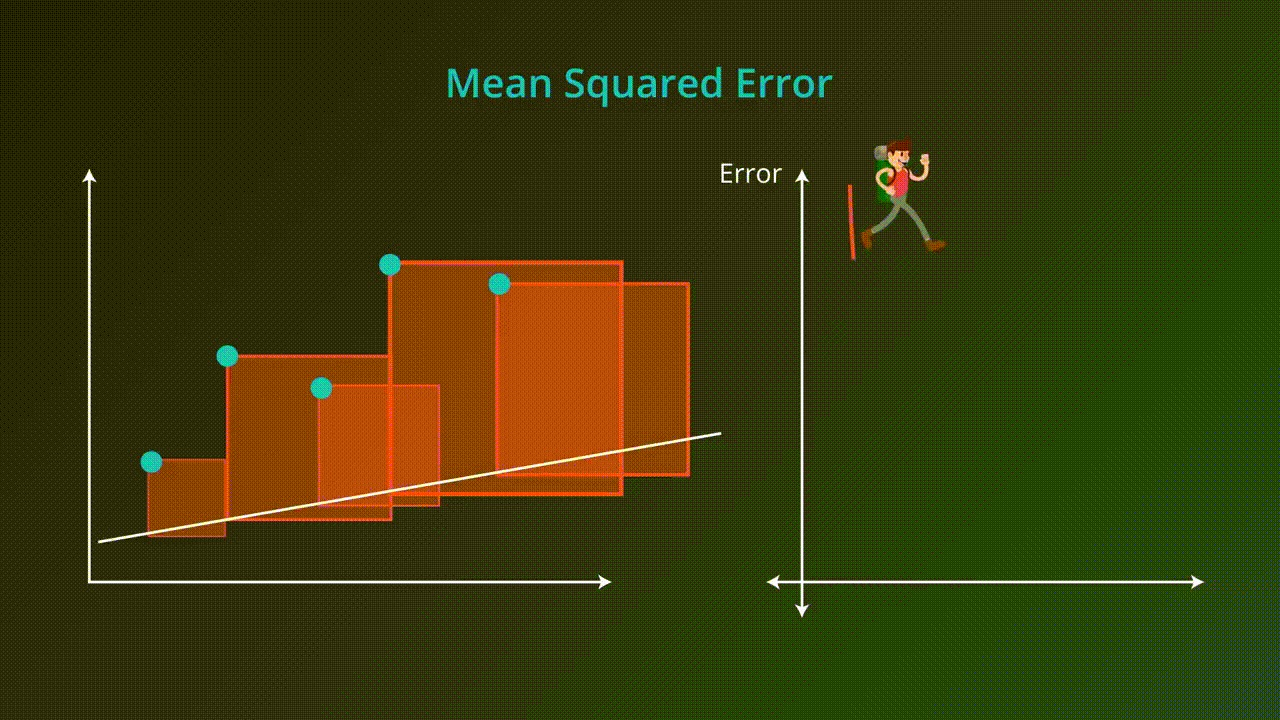

In [4]:
def mse(y_true, y_pred):
    """Mean Squared Error."""
    return np.mean((y_pred - y_true) ** 2)


for model in candidates:
    y_hat = linear_model_1d(x, model["w0"], model["w1"])
    cost = mse(y, y_hat)
    print(f'{model["name"]}: w0={model["w0"]:.2f}, w1={model["w1"]:.2f}, MSE={cost:.3f}')

Modelo A: w0=0.00, w1=0.50, MSE=60.017
Modelo B: w0=2.00, w1=1.50, MSE=0.960
Modelo C: w0=8.00, w1=0.40, MSE=12.484


<div style="background:rgba(60,125,60,0.14);border-left:5px solid #3c7d3c;padding:14px;border-radius:6px;color:inherit">

### Interpretación

El MSE penaliza mucho los errores grandes porque eleva las diferencias al cuadrado.

Si el modelo predice $\hat{y}_i$ y la etiqueta real es $y_i$, el error individual es:

$$
e_i = \hat{y}_i - y_i
$$

y su contribución al coste es:

$$
e_i^2
$$

</div>

## 10. Cálculo manual del MSE

Considera tres muestras:

| $x_i$ | $y_i$ |
|---:|---:|
| 1 | 3 |
| 2 | 5 |
| 3 | 7 |

y el modelo:

$$
\hat{y} = 1 + 2x
$$

Calculamos:

| $x_i$ | $y_i$ | $\hat{y}_i$ | $\hat{y}_i - y_i$ | $(\hat{y}_i - y_i)^2$ |
|---:|---:|---:|---:|---:|
| 1 | 3 | 3 | 0 | 0 |
| 2 | 5 | 5 | 0 | 0 |
| 3 | 7 | 7 | 0 | 0 |

Por tanto:

$$
MSE = \frac{0 + 0 + 0}{3} = 0
$$

Este modelo ajusta perfectamente esos tres puntos.

In [5]:
# Comprobamos el cálculo anterior con NumPy
x_small = np.array([1, 2, 3])
y_small = np.array([3, 5, 7])

y_hat_small = 1 + 2 * x_small

print("Predicciones:", y_hat_small)
print("MSE:", mse(y_small, y_hat_small))

Predicciones: [3 5 7]
MSE: 0.0


## 11. Superficie de coste

En regresión lineal 1D, el coste depende de dos parámetros:

$$
J(w_0, w_1)
$$

Podemos calcular el MSE para muchos pares $(w_0, w_1)$ y visualizar dónde se encuentra la zona de menor error.

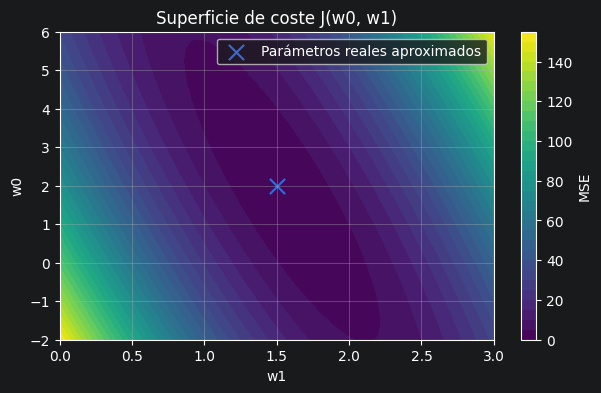

In [6]:
# Malla de posibles valores de parámetros
w0_values = np.linspace(-2, 6, 80)
w1_values = np.linspace(0, 3, 80)

J = np.zeros((len(w0_values), len(w1_values)))

for i, w0 in enumerate(w0_values):
    for j, w1 in enumerate(w1_values):
        y_hat = linear_model_1d(x, w0, w1)
        J[i, j] = mse(y, y_hat)

# Representación en contorno
W1, W0 = np.meshgrid(w1_values, w0_values)

plt.contourf(W1, W0, J, levels=30)
plt.colorbar(label="MSE")
plt.xlabel("w1")
plt.ylabel("w0")
plt.title("Superficie de coste J(w0, w1)")
plt.scatter([1.5], [2.0], marker="x", s=120, label="Parámetros reales aproximados")
plt.legend()
plt.show()

## 12. Entrenamiento con `scikit-learn`

Aunque en Deep Learning entrenaremos redes neuronales, es útil repasar primero un modelo lineal clásico.

En `scikit-learn`, el método habitual es:

1. Crear el modelo.
2. Entrenarlo con `.fit(X_train, y_train)`.
3. Predecir con `.predict(X_test)`.
4. Evaluar el error.

w0 aprendido (intercept): 1.8592775823585983
w1 aprendido (coef): 1.537328084153543
MSE en todo el dataset: 0.9453602261304077


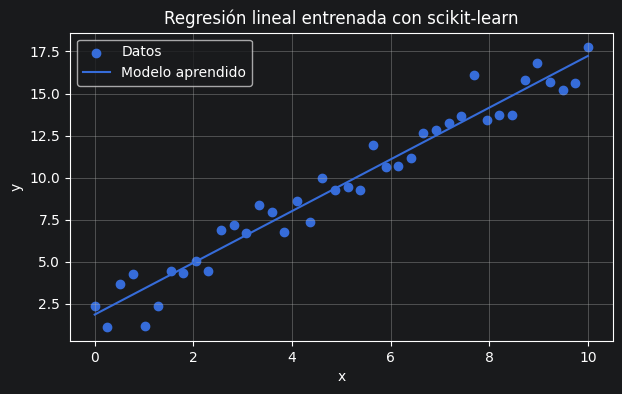

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# sklearn espera X como matriz: (n_muestras, n_características)
X = x.reshape(-1, 1)

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("w0 aprendido (intercept):", model.intercept_)
print("w1 aprendido (coef):", model.coef_[0])
print("MSE en todo el dataset:", mean_squared_error(y, y_pred))

plt.scatter(x, y, label="Datos")
plt.plot(x, y_pred, label="Modelo aprendido")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regresión lineal entrenada con scikit-learn")
plt.legend()
plt.show()

## 13. Evaluación: resustitución, hold-out y cross-validation

### Resustitución

Entrenar y evaluar con los mismos datos.

- Ventaja: usa todos los datos para entrenar.
- Problema: suele dar una estimación demasiado optimista.

### Hold-out

Dividir los datos en entrenamiento y test.

Normalmente:

$$
80\% \text{ entrenamiento}, \quad 20\% \text{ test}
$$

- Ventaja: evalúa con datos no usados para entrenar.
- Problema: el resultado depende de la partición.

### Cross-validation

Dividir el dataset en $V$ grupos o folds.

En cada iteración:

- se entrena con $V-1$ folds;
- se evalúa con el fold restante;
- se promedian los errores.

Si $V=N$, se llama **leave-one-out**.

In [8]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# Hold-out
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

holdout_model = LinearRegression()
holdout_model.fit(X_train, y_train)

train_pred = holdout_model.predict(X_train)
test_pred = holdout_model.predict(X_test)

print("MSE entrenamiento:", mean_squared_error(y_train, train_pred))
print("MSE test:", mean_squared_error(y_test, test_pred))
print("Tamaño train:", X_train.shape[0])
print("Tamaño test:", X_test.shape[0])

MSE entrenamiento: 0.9133370641579317
MSE test: 1.1384285722286802
Tamaño train: 32
Tamaño test: 8


In [9]:
# Cross-validation con 5 folds
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# cross_val_score maximiza score; usamos neg_mean_squared_error y cambiamos signo
negative_mse_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    scoring="neg_mean_squared_error",
    cv=cv
)

mse_scores = -negative_mse_scores

print("MSE por fold:", np.round(mse_scores, 3))
print("MSE medio CV:", np.mean(mse_scores).round(3))
print("Desviación típica:", np.std(mse_scores).round(3))

MSE por fold: [1.138 0.527 1.119 1.539 0.893]
MSE medio CV: 1.043
Desviación típica: 0.332


<div style="background:rgba(217,154,0,0.14);border-left:5px solid #d99a00;padding:14px;border-radius:6px;color:inherit">

### Pregunta típica

Si tienes 1000 datos y haces 5-fold cross-validation:

- Número de entrenamientos: $5$.
- Datos de test por entrenamiento: $1000 / 5 = 200$.
- Error estimado: media de los errores de los 5 folds.

</div>

## 14. Vectorización y dimensiones

En Deep Learning se trabaja casi siempre con matrices y tensores. Antes de llegar a redes neuronales, hay que dominar esta idea.

Supongamos:

$$
\mathbf{X} \in \mathbb{R}^{100 \times 20}
$$

Esto significa:

- 100 muestras;
- 20 características por muestra.

Y un modelo lineal:

$$
\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b
$$

con:

$$
\mathbf{w} \in \mathbb{R}^{20 \times 1}
$$

Entonces:

$$
\mathbf{X}\mathbf{w} \in \mathbb{R}^{100 \times 1}
$$

In [10]:
# Ejemplo de dimensiones
X_demo = rng.normal(size=(100, 20))
w_demo = rng.normal(size=(20, 1))
b_demo = 3.0

y_demo = X_demo @ w_demo + b_demo

print("X_demo shape:", X_demo.shape)
print("w_demo shape:", w_demo.shape)
print("y_demo shape:", y_demo.shape)

X_demo shape: (100, 20)
w_demo shape: (20, 1)
y_demo shape: (100, 1)


## 15. Del bucle a la versión vectorizada

Una implementación con bucle procesa una muestra cada vez.

Una implementación vectorizada procesa todas las muestras a la vez.

La versión vectorizada es:

$$
\mathbf{Y} = \mathbf{X}\mathbf{w} + b
$$

En NumPy:

```python
y = X @ w + b
```

In [11]:
# Datos de ejemplo
X_vec = rng.normal(size=(100, 10))
w_vec = rng.normal(size=(10, 1))
b_vec = 3.0

def f_single(x_i, w, b):
    """
    Calcula la salida para una única muestra.
    x_i debe tener shape (10, 1).
    w debe tener shape (10, 1).
    """
    return w.T @ x_i + b

# Versión con bucle
y_loop = []

for i in range(X_vec.shape[0]):
    x_i = X_vec[i, :].reshape(-1, 1)
    y_loop.append(f_single(x_i, w_vec, b_vec))

y_loop = np.vstack(y_loop)

# Versión vectorizada
y_vectorized = X_vec @ w_vec + b_vec

print("Shape con bucle:", y_loop.shape)
print("Shape vectorizada:", y_vectorized.shape)
print("¿Son iguales?", np.allclose(y_loop, y_vectorized))

Shape con bucle: (100, 1)
Shape vectorizada: (100, 1)
¿Son iguales? True


## 16. Clasificación binaria como modelo supervisado

En clasificación binaria, las etiquetas suelen ser:

$$
y \in \{0, 1\}
$$

Un modelo produce una puntuación o probabilidad y después se decide la clase.

Por ejemplo:

$$
\hat{p} = P(y=1|\mathbf{x})
$$

Si:

$$
\hat{p} \geq 0.5
$$

se predice clase 1. En caso contrario, clase 0.

In [12]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X_clf, y_clf = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

clf = LogisticRegression()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.933
Matriz de confusión:
[[34  4]
 [ 1 36]]


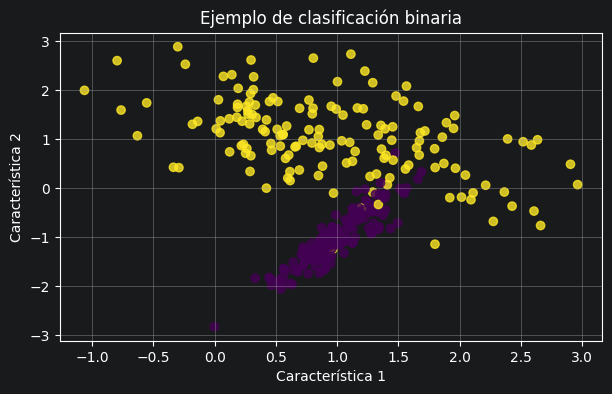

In [13]:
plt.scatter(X_clf[:, 0], X_clf[:, 1], c=y_clf, alpha=0.8)
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title("Ejemplo de clasificación binaria")
plt.show()

## 17. Underfitting y overfitting

Un modelo puede generalizar mal por dos motivos principales.

### Underfitting

El modelo es demasiado simple y no captura la estructura de los datos.

Ejemplo:

$$
\hat{y} = w_0
$$

Es decir, una constante para todo.

### Overfitting

El modelo es demasiado complejo y se ajusta demasiado a las peculiaridades del entrenamiento.

Ejemplo:

$$
\hat{y} = w_0 + w_1x + w_2x^2 + \dots + w_{15}x^{15}
$$

El objetivo real no es minimizar el error de entrenamiento a cualquier precio, sino conseguir buena **generalización**.

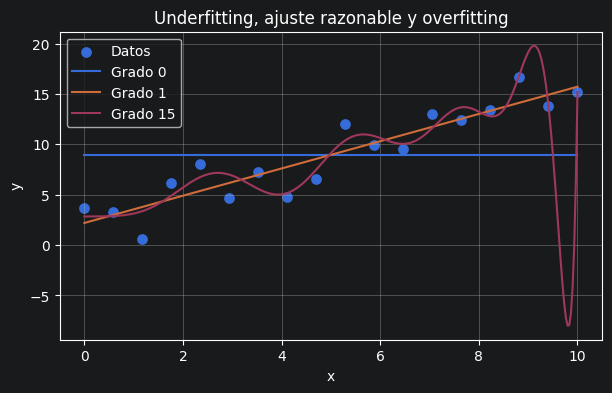

In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Datos más pequeños para visualizar overfitting
x_poly = np.linspace(0, 10, 18)
y_poly = 2 + 1.5 * x_poly + rng.normal(0, 2.0, size=x_poly.shape)

X_poly = x_poly.reshape(-1, 1)
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

degrees = [0, 1, 15]

plt.scatter(x_poly, y_poly, label="Datos", s=45)

for degree in degrees:
    poly_model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    poly_model.fit(X_poly, y_poly)
    y_plot = poly_model.predict(x_plot)
    plt.plot(x_plot.ravel(), y_plot, label=f"Grado {degree}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Underfitting, ajuste razonable y overfitting")
plt.legend()
plt.show()

## 18. Conexión con Deep Learning

Una red neuronal profunda también es una función parametrizada:

$$
\hat{\mathbf{y}} = f(\mathbf{x}; \boldsymbol{\theta})
$$

La diferencia es que ahora los parámetros $\boldsymbol{\theta}$ pueden incluir:

- matrices de pesos de muchas capas;
- vectores de bias;
- parámetros de normalización;
- embeddings;
- filtros convolucionales.

Pero el esquema general se mantiene:

1. Definir un modelo.
2. Calcular predicciones.
3. Medir una pérdida.
4. Actualizar parámetros.
5. Evaluar generalización.

Este patrón aparecerá en todos los temas de Deep Learning.

# 19. Ejercicios tipo examen resueltos

En esta sección se resuelven ejercicios representativos del Tema 1.

La idea no es memorizar respuestas, sino aprender a razonar:

- dimensiones de matrices;
- diferencia entre entrenamiento e inferencia;
- validación cruzada;
- vectorización;
- errores numéricos como `NaN`.

## Ejercicio 1 — Operaciones con matrices

Dadas:

$$
\mathbf{A} \in \mathbb{R}^{20 \times 30}, \quad
\mathbf{B} \in \mathbb{R}^{20 \times 30}
$$

Determina qué operación es correcta:

1. $\mathbf{A}\mathbf{B} = \mathbf{B}^T\mathbf{A}^T$
2. $\mathbf{B}\mathbf{A} = \mathbf{A}\mathbf{B}$
3. $\mathbf{B}^T\mathbf{A} = (\mathbf{A}^T\mathbf{B})^T$
4. Ninguna

### Solución

La opción correcta es:

$$
\mathbf{B}^T\mathbf{A} = (\mathbf{A}^T\mathbf{B})^T
$$

porque se cumple la propiedad:

$$
(\mathbf{M}\mathbf{N})^T = \mathbf{N}^T\mathbf{M}^T
$$

Si tomamos $\mathbf{M}=\mathbf{A}^T$ y $\mathbf{N}=\mathbf{B}$:

$$
(\mathbf{A}^T\mathbf{B})^T = \mathbf{B}^T(\mathbf{A}^T)^T = \mathbf{B}^T\mathbf{A}
$$

In [15]:
# Comprobación numérica
A = rng.normal(size=(20, 30))
B = rng.normal(size=(20, 30))

left = B.T @ A
right = (A.T @ B).T

print("Shape izquierda:", left.shape)
print("Shape derecha:", right.shape)
print("¿Son iguales?", np.allclose(left, right))

Shape izquierda: (30, 30)
Shape derecha: (30, 30)
¿Son iguales? True


## Ejercicio 2 — Modelo lineal e inferencia

Se pretende usar el modelo:

$$
f(\mathbf{x}, \mathbf{w}) = w_0 + w_1x_1 + w_2x_2
$$

¿Cuál es la afirmación incorrecta?

1. El modelo es lineal en los parámetros.
2. Los valores de $\mathbf{w}$ optimizan el error cuadrático medio en entrenamiento.
3. En entrenamiento se encuentran los valores de $\mathbf{w}$.
4. En inferencia se estiman los valores $w_0$ y $w_1$.

### Solución

La afirmación incorrecta es la 4.

En inferencia **no se estiman los parámetros**.  
En inferencia se usan los parámetros ya aprendidos para calcular la salida.

Los parámetros se estiman durante el entrenamiento.

## Ejercicio 3 — Cross-validation

Tenemos 1000 datos y hacemos 5-fold cross-validation.  
Los errores obtenidos son:

$$
5\%,\; 4.5\%,\; 5.5\%,\; 9\%,\; 1\%
$$

Calcular:

- número de entrenamientos $F$;
- número de datos de test por entrenamiento $N_{test}$;
- error medio estimado $E$.

### Solución

Número de entrenamientos:

$$
F = 5
$$

Datos de test por fold:

$$
N_{test} = \frac{1000}{5} = 200
$$

Error medio:

$$
E = \frac{5 + 4.5 + 5.5 + 9 + 1}{5} = 5\%
$$

In [16]:
errors = np.array([5.0, 4.5, 5.5, 9.0, 1.0])

F = len(errors)
N_total = 1000
N_test = N_total // F
E = errors.mean()

print("F:", F)
print("N_test:", N_test)
print("E:", E, "%")

F: 5
N_test: 200
E: 5.0 %


## Ejercicio 4 — Implementación vectorizada

Dado:

$$
\mathbf{X} \in \mathbb{R}^{100 \times 20}, \quad
\mathbf{w} \in \mathbb{R}^{20 \times 1}, \quad
b \in \mathbb{R}
$$

¿Cuáles son correctas?

```python
y = (w.T @ X.T + b).T
y = X @ w + b
y = np.dot(X, w) + b
```

### Solución

Las tres son correctas.

La forma más clara suele ser:

```python
y = X @ w + b
```

porque respeta directamente la notación:

$$
\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b
$$

In [17]:
X_ex = rng.normal(size=(100, 20))
w_ex = rng.normal(size=(20, 1))
b_ex = 1.5

y1 = (w_ex.T @ X_ex.T + b_ex).T
y2 = X_ex @ w_ex + b_ex
y3 = np.dot(X_ex, w_ex) + b_ex

print(y1.shape, y2.shape, y3.shape)
print("y1 == y2:", np.allclose(y1, y2))
print("y2 == y3:", np.allclose(y2, y3))

(100, 1) (100, 1) (100, 1)
y1 == y2: True
y2 == y3: True


## Ejercicio 5 — Elegir la implementación correcta

Dado:

$$
\mathbf{X} \in \mathbb{R}^{50 \times 10}, \quad
\mathbf{w} \in \mathbb{R}^{10 \times 1}
$$

La salida esperada debe tener forma:

$$
\hat{\mathbf{y}} \in \mathbb{R}^{50 \times 1}
$$

Entre las opciones:

```python
y = w.T @ X.T + b
y = X.T @ w + b
y = np.dot(X, w.T) + b
y = (w.T @ X.T + b).T
```

La correcta es:

```python
y = (w.T @ X.T + b).T
```

Aunque la forma más natural sería:

```python
y = X @ w + b
```

La primera opción produce una salida de forma `(1, 50)`, no `(50, 1)`.

In [18]:
X_ex = rng.normal(size=(50, 10))
w_ex = rng.normal(size=(10, 1))
b_ex = 0.2

y_correct = (w_ex.T @ X_ex.T + b_ex).T
y_natural = X_ex @ w_ex + b_ex

print("Shape correcta:", y_correct.shape)
print("¿Equivale a X @ w + b?", np.allclose(y_correct, y_natural))

Shape correcta: (50, 1)
¿Equivale a X @ w + b? True


## Ejercicio 6 — Resultado `NaN` en una derivada

Se tiene:

$$
\frac{\partial L}{\partial \theta}
=
\frac{y - f(x,\theta)}{|y - f(x,\theta)|} \cdot \theta
$$

con:

$$
f(x,\theta)=x-\theta,\quad y=1,\quad x=2
$$

Sustituimos:

$$
y - f(x,\theta)
=
1 - (2 - \theta)
=
\theta - 1
$$

La expresión problemática es:

$$
\frac{\theta - 1}{|\theta - 1|}
$$

Habrá `NaN` cuando el numerador y el denominador sean cero:

$$
\theta - 1 = 0
$$

Por tanto:

$$
\theta = 1
$$

In [19]:
theta_values = np.array([2, 1, 0, -1], dtype=float)

for theta in theta_values:
    numerator = theta - 1
    denominator = abs(theta - 1)

    with np.errstate(divide="ignore", invalid="ignore"):
        derivative = (numerator / denominator) * theta

    print(f"theta={theta:>4}: derivada={derivative}")

theta= 2.0: derivada=2.0
theta= 1.0: derivada=nan
theta= 0.0: derivada=-0.0
theta=-1.0: derivada=1.0


## Ejercicio 7 — Vectorización de un bucle

Código original:

```python
X = np.random.randn(100, 10)
w = np.random.randn(10, 1)
b = 3

def f(x, w, b):
    return w.T @ x + b

y = []
for i in range(X.shape[0]):
    y.append(f(X[i, ...].T, w, b))

y = np.stack(y, 0)
```

La versión vectorizada correcta es:

```python
y = X @ w + b
```

porque:

$$
\mathbf{X} \in \mathbb{R}^{100 \times 10}
$$

$$
\mathbf{w} \in \mathbb{R}^{10 \times 1}
$$

entonces:

$$
\mathbf{X}\mathbf{w} \in \mathbb{R}^{100 \times 1}
$$

In [20]:
X = rng.normal(size=(100, 10))
w = rng.normal(size=(10, 1))
b = 3

def f(x, w, b):
    return w.T @ x + b

y_loop = []

for i in range(X.shape[0]):
    x_i = X[i, :].reshape(-1, 1)
    y_loop.append(f(x_i, w, b))

y_loop = np.vstack(y_loop)
y_vec = X @ w + b

print("Shape y_loop:", y_loop.shape)
print("Shape y_vec:", y_vec.shape)
print("¿Coinciden?", np.allclose(y_loop, y_vec))

Shape y_loop: (100, 1)
Shape y_vec: (100, 1)
¿Coinciden? True


# 20. Resumen final

| Concepto | Idea clave |
|---|---|
| Modelo supervisado | Función que aprende de pares entrada/salida |
| Parámetros | Valores internos que se ajustan durante entrenamiento |
| Inferencia | Calcular la salida usando parámetros ya aprendidos |
| Entrenamiento | Encontrar los parámetros que minimizan el coste |
| MSE | Media de los errores al cuadrado |
| Hold-out | Entrenar y evaluar con particiones separadas |
| Cross-validation | Entrenar varias veces usando folds |
| Vectorización | Sustituir bucles por operaciones matriciales |
| Underfitting | Modelo demasiado simple |
| Overfitting | Modelo demasiado complejo y poco generalizable |

---

## Checklist de dominio del Tema 1

Antes de pasar al siguiente tema, deberías poder responder:

- ¿Qué diferencia hay entre regresión y clasificación?
- ¿Qué diferencia hay entre entrenamiento e inferencia?
- ¿Qué representa $\mathbf{X} \in \mathbb{R}^{N \times d}$?
- ¿Por qué `X @ w + b` es una implementación vectorizada?
- ¿Qué mide una función de coste?
- ¿Qué problema tiene evaluar con los mismos datos usados para entrenar?
- ¿Cómo se calcula el error medio en cross-validation?
- ¿Qué provoca un `NaN` en una división tipo $0/0$?

# 21. Mini práctica propuesta

Completa o modifica este notebook para practicar:

1. Cambia el nivel de ruido en los datos de regresión.
2. Prueba varios porcentajes de `test_size`.
3. Cambia `n_splits` en cross-validation.
4. Genera un dataset de clasificación con más muestras.
5. Comprueba manualmente las formas de matrices en todos los productos.
6. Añade un modelo polinómico de grado 3 y compara su MSE con el modelo lineal.

Estas pequeñas modificaciones ayudan a entender mejor el comportamiento real de los modelos.